# Пишем CatBoost своими руками: Шаги Ньютона и L2-Scoring

В этом ноутбуке мы заглянем «под капот» градиентного бустинга. Мы напишем с нуля кастомный движок на Python, который математически точно повторяет логику оригинального C++ движка CatBoost.

**Мы разберем:**
* Вычисление **L2-score** для поиска оптимальных сплитов.
* Выполнение **шага Ньютона (Newton leaf estimation)** для обновления вероятностей.
* Работу с пропусками (NaNs) и эмуляцию стратегии `nan_mode='Min'`.

In [1]:
!pip install catboost -q

import os
import io
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

# Для пользователей Windows с проблемами отрисовки деревьев Graphviz раскомментируйте строку ниже и укажите свой путь:
# os.environ["PATH"] += os.pathsep + r'C:\Users\YourName\Graphviz\bin'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


## 1. Кастомный движок бустинга

Здесь собраны основные функции: поиск масок листьев, расчет наилучшего сплита на основе максимизации `L2-score` и обновление вероятностей по формуле `Newton leaf estimation`.

Мы также написали универсальную функцию `parse_borders` для извлечения границ квантизации напрямую из файла CatBoost. Чтобы не дублировать код, мы собрали логику в функцию `fit_custom_catboost`.

In [2]:
def parse_borders(filepath):
    """Парсит файл с границами квантизации CatBoost в словарь."""
    borders_dict = {}
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                feat_idx = int(parts[0])
                border_val = float(parts[1])
                if feat_idx not in borders_dict:
                    borders_dict[feat_idx] = []
                borders_dict[feat_idx].append(border_val)
    return borders_dict

def get_leaves_masks(df, tree):
    """Возвращает маски строк для каждого листа дерева."""
    if not tree:
        return {"Root (All Data)": pd.Series(True, index=df.index)}

    list_of_branches = [([], pd.Series(True, index=df.index))]

    for column_to_check, split_value in tree:
        new_cut_pieces = []
        for current_rules, current_mask in list_of_branches:
            is_left_side = (df[column_to_check] <= split_value)
            left_mask = current_mask & is_left_side
            new_cut_pieces.append((current_rules + [f"{column_to_check}<={split_value:.3f}"], left_mask))

            is_right_side = (df[column_to_check] > split_value)
            right_mask = current_mask & is_right_side
            new_cut_pieces.append((current_rules + [f"{column_to_check}>{split_value:.3f}"], right_mask))

        list_of_branches = new_cut_pieces

    return {" & ".join(rules): mask for rules, mask in list_of_branches}

def find_best_split(df, tree, features, borders_dict, l2_reg):
    """Ищет лучший сплит, который строго максимизирует сумму L2-score."""
    leaf_masks_dict = get_leaves_masks(df, tree)

    current_score = 0
    for mask in leaf_masks_dict.values():
        w = mask.sum()
        if w > 0:
            sum_grad = df.loc[mask, 'gradient'].sum()
            current_score += (sum_grad**2) / (w + l2_reg)

    best_score = current_score + 1e-9
    best_split = None

    for feat_idx, feature in enumerate(features):
        if feat_idx not in borders_dict:
            continue

        borders = borders_dict[feat_idx]
        for border in borders:
            is_left = (df[feature] <= border) | df[feature].isna()

            if is_left.sum() == 0 or (~is_left).sum() == 0:
                continue

            total_score = 0
            for mask in leaf_masks_dict.values():
                mask_l = mask & is_left
                mask_r = mask & (~is_left)

                w_left = mask_l.sum()
                w_right = mask_r.sum()

                sum_grad_l = df.loc[mask_l, 'gradient'].sum() if w_left > 0 else 0
                sum_grad_r = df.loc[mask_r, 'gradient'].sum() if w_right > 0 else 0

                score_l = (sum_grad_l**2) / (w_left + l2_reg) if w_left > 0 else 0
                score_r = (sum_grad_r**2) / (w_right + l2_reg) if w_right > 0 else 0

                total_score += score_l + score_r

            if total_score > best_score:
                best_score = total_score
                best_split = (feature, border)

    return best_split

def update_predictions(df, tree, lr, l2_reg, verbose=True):
    """Шаг Ньютона для вычисления значения в листе и обновления лог-шансов."""
    leaf_masks_dict = get_leaves_masks(df, tree)
    new_probs = pd.Series(index=df.index, dtype=float)

    for leaf_name, mask in leaf_masks_dict.items():
        if not mask.any():
            continue

        sum_grad = df.loc[mask, 'gradient'].sum()
        sum_hess = df.loc[mask, 'hessian'].sum()

        leaf_value = (sum_grad / (sum_hess + l2_reg)) * lr

        if verbose:
            print(f"    Leaf Value: {leaf_value:>7.4f} | Rows: {mask.sum():>4} | Filters: [{leaf_name}]")

        p = df.loc[mask, 'pred_prob']
        p_safe = np.clip(p, 1e-15, 1 - 1e-15)
        new_log_odds = np.log(p_safe / (1 - p_safe)) + leaf_value
        new_probs.loc[mask] = 1 / (1 + np.exp(-new_log_odds))

    return new_probs

def fit_custom_catboost(df, features, target, borders_dict, iterations, depth, learning_rate, l2_reg, verbose=True):
    """Главный цикл обучения."""
    df = df.copy()
    df['pred_prob'] = 0.5

    for i in range(iterations):
        if verbose:
            print(f"\n{'='*60}\nTree {i+1}\n{'='*60}")

        df['gradient'] = df[target] - df['pred_prob']
        df['hessian']  = df['pred_prob'] * (1 - df['pred_prob'])
        tree = []

        for d in range(depth):
            best_split = find_best_split(df, tree, features, borders_dict, l2_reg)
            if best_split is None:
                if verbose:
                    print(f"  [✂️ CROPPED] Остановлено на глубине {d} (нет сплитов, улучшающих L2-score)")
                break
            tree.append(best_split)

        if verbose:
            print("  Structure:")
            if not tree:
                print("    [Empty Tree]")
            for lvl, (f, v) in enumerate(tree):
                print(f"    Level {lvl+1}: {f} <= {v}")
            print("\n  Leaves Applied:")

        df['pred_prob'] = update_predictions(df, tree, learning_rate, l2_reg, verbose)

    return df['pred_prob']

## 2. Разбираем математику на простых данных (Toy Dataset)

Сгенерируем датасет с кредитными рисками, чтобы посмотреть, как алгоритм выбирает сплиты и считает значения листьев на наглядном примере. Для визуализации добавим график.

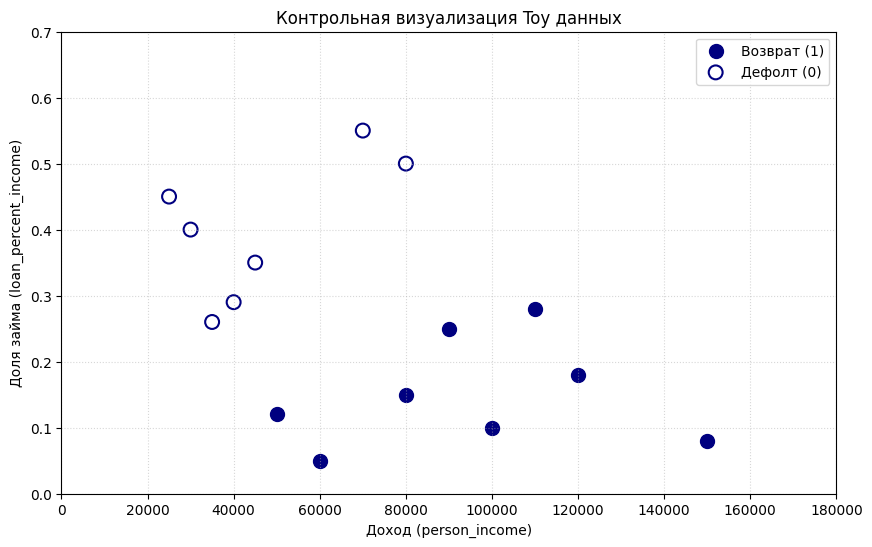

In [3]:
df_toy = pd.DataFrame({
    'person_income':       [100000, 80000, 60000, 120000, 50000, 150000,  30000, 45000, 80000, 25000, 70000,   90000, 110000,  35000, 40000],
    'loan_percent_income': [  0.10,  0.15,  0.05,   0.18,  0.12,   0.08,   0.40,  0.35,  0.50,  0.45,  0.55,    0.25,   0.28,   0.26,  0.29],
    'person_age':          [    25,    42,    55,     30,    48,     41,     22,    38,    60,    28,    33,      45,     24,     50,    35],
    'loan_status':         [     1,     1,     1,      1,     1,      1,      0,     0,     0,     0,     0,       1,      1,      0,     0]
})
target_toy = 'loan_status'
features_toy = ['loan_percent_income', 'person_income']

plt.figure(figsize=(10, 6))
status_1 = df_toy[df_toy['loan_status'] == 1]
status_0 = df_toy[df_toy['loan_status'] == 0]

plt.scatter(status_1['person_income'], status_1['loan_percent_income'],
            color='navy', marker='o', s=100, label='Возврат (1)')
plt.scatter(status_0['person_income'], status_0['loan_percent_income'],
            facecolors='none', edgecolors='navy', marker='o', s=100, linewidths=1.5, label='Дефолт (0)')

plt.xlim(0, 180000)
plt.ylim(0, 0.7)
plt.xlabel('Доход (person_income)')
plt.ylabel('Доля займа (loan_percent_income)')
plt.title('Контрольная визуализация Toy данных')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [4]:
cb_params_toy = {
  'iterations': 2,
  'depth': 4,
  'learning_rate': 0.8,
  'random_seed': 1,
  'reg_lambda': 3.0,
  'bootstrap_type': 'No',
  'penalties_coefficient': 0,
  'langevin': False,
  'diffusion_temperature': 0,
  'random_strength': 0,
  'logging_level': 'Silent',
  'score_function': 'L2',
  'leaf_estimation_method': 'Newton'
}

pool_toy = Pool(df_toy[features_toy], df_toy[target_toy])
pool_toy.quantize()
pool_toy.save_quantization_borders('border_toy.txt')
borders_dict_toy = parse_borders('border_toy.txt')

print("⏳ Обучение оригинального CatBoost...")
model_toy = CatBoostClassifier(**cb_params_toy).fit(pool_toy)
l2_reg_toy = model_toy.get_all_params()['l2_leaf_reg']

print("\n🚀 Запуск ручной реализации (Toy Dataset)...")
custom_pred_toy = fit_custom_catboost(
    df_toy, features_toy, target_toy, borders_dict_toy,
    cb_params_toy['iterations'], cb_params_toy['depth'],
    cb_params_toy['learning_rate'], l2_reg_toy
)

cb_pred_toy = model_toy.predict_proba(pool_toy)[:, 1]
max_diff_toy = (cb_pred_toy - custom_pred_toy).abs().max()

print("\n" + "="*80)
print(f"🎯 Максимальная разница вероятностей (Toy): {max_diff_toy:.12f}")
if max_diff_toy < 1e-7:
    print("✅ SUCCESS! Идеальное математическое совпадение.")
else:
    print("❌ Найдены расхождения.")
print("="*80)

⏳ Обучение оригинального CatBoost...

🚀 Запуск ручной реализации (Toy Dataset)...

Tree 1
  [✂️ CROPPED] Остановлено на глубине 2 (нет сплитов, улучшающих L2-score)
  Structure:
    Level 1: loan_percent_income <= 0.2549999952
    Level 2: person_income <= 105000.0

  Leaves Applied:
    Leaf Value:  0.4706 | Rows:    5 | Filters: [loan_percent_income<=0.255 & person_income<=105000.000]
    Leaf Value:  0.2286 | Rows:    2 | Filters: [loan_percent_income<=0.255 & person_income>105000.000]
    Leaf Value: -0.5895 | Rows:    7 | Filters: [loan_percent_income>0.255 & person_income<=105000.000]
    Leaf Value:  0.1231 | Rows:    1 | Filters: [loan_percent_income>0.255 & person_income>105000.000]

Tree 2
  [✂️ CROPPED] Остановлено на глубине 2 (нет сплитов, улучшающих L2-score)
  Structure:
    Level 1: loan_percent_income <= 0.2849999964
    Level 2: person_income <= 37500.0

  Leaves Applied:
    Leaf Value: -0.0884 | Rows:    1 | Filters: [loan_percent_income<=0.285 & person_income<=3750

## 3. Боевое тестирование на Titanic (Трюк с NaN)

На реальных датасетах часто встречаются пропуски (`NaN`). По умолчанию CatBoost использует стратегию обработки пропусков `nan_mode='Min'`, что означает, что при квантизации и поиске сплитов алгоритм отправляет все `NaN` в самое левое поддерево (считает их меньше любого другого значения).

Чтобы сымитировать это поведение на уровне чистой математики (Pandas/Numpy), мы заполним пропуски экстремально маленьким числом `-999`. Это элегантный хак, который позволяет нашему кастомному движку без изменения логики сплитов обрабатывать `NaN` точно так же, как это делает C++ движок CatBoost.

In [5]:
print("⏳ Загрузка датасета Titanic...")
try:
    df_raw = sns.load_dataset('titanic')
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df_raw = pd.read_csv(url)
    df_raw.columns = [c.lower() for c in df_raw.columns]

features_tit = ['pclass', 'age', 'sibsp', 'parch', 'fare']
target_tit = 'survived'
df_titanic = df_raw[features_tit + [target_tit]].copy()

# ХАК: Заменяем пропуски на -999, чтобы эмулировать логику nan_mode='Min'
df_titanic = df_titanic.fillna(-999)
print(f"Размер датасета: {df_titanic.shape[0]} строк. Все пропуски заменены на -999.\n")

cb_params_tit = {
  'iterations': 5,
  'depth': 10,
  'learning_rate': 0.5,
  'random_seed': 42,
  'reg_lambda': 3.0,
  'bootstrap_type': 'No',
  'penalties_coefficient': 0,
  'langevin': False,
  'diffusion_temperature': 0,
  'random_strength': 0,
  'logging_level': 'Silent',
  'score_function': 'L2',
  'leaf_estimation_method': 'Newton'
}

print("⏳ Квантизация признаков...")
pool_tit = Pool(df_titanic[features_tit], df_titanic[target_tit])
pool_tit.quantize()
pool_tit.save_quantization_borders('titanic_borders.txt')
borders_dict_tit = parse_borders('titanic_borders.txt')

print("⏳ Обучение оригинального CatBoost...")
model_tit = CatBoostClassifier(**cb_params_tit).fit(pool_tit)
l2_reg_tit = model_tit.get_all_params()['l2_leaf_reg']
cb_pred_tit = model_tit.predict_proba(pool_tit)[:, 1]

print("🚀 Запуск ручной реализации (Custom Engine)...")
custom_pred_tit = fit_custom_catboost(
    df_titanic, features_tit, target_tit, borders_dict_tit,
    cb_params_tit['iterations'], cb_params_tit['depth'],
    cb_params_tit['learning_rate'], l2_reg_tit,
    verbose=False  # Отключаем логи, чтобы не перегружать вывод
)

max_diff_tit = (cb_pred_tit - custom_pred_tit).abs().max()
print("\n" + "="*80)
print(f"🎯 Максимальная разница вероятностей (Titanic): {max_diff_tit:.12f}")
if max_diff_tit < 1e-7:
    print("✅ УСПЕХ! Математика идеальна! Реализация совпала с CatBoost на Титанике!")
else:
    print("❌ Найдены расхождения.")
print("="*80)

⏳ Загрузка датасета Titanic...
Размер датасета: 891 строк. Все пропуски заменены на -999.

⏳ Квантизация признаков...
⏳ Обучение оригинального CatBoost...
🚀 Запуск ручной реализации (Custom Engine)...

🎯 Максимальная разница вероятностей (Titanic): 0.000000000000
✅ УСПЕХ! Математика идеальна! Реализация совпала с CatBoost на Титанике!
